## <b><u>Infrared.city-1</u>: Tree detection</b>
### <b>Introduction</b>

As urban areas are expanding and global temperatures rise due to climate change, being able to understand how trees can help cool cities has become increasingly important. Furthermore, trees reduce the risk of flooding in cities and promote health and wellbeing. Our project aims at taking the first step in the direction of better tree coverage in urban areas by creating a model which is able to predict tree locations using satellite imagery of densely populated areas. <i>In this notebook we will fetch and prepear the data:</i>

### <b>Notebook structure 2</b>

&nbsp;&nbsp;&nbsp;<b>1. Fetching cleaned sentinel and messy osm data</b><br>
&nbsp;&nbsp;&nbsp;<b>2. Checking osm data</b><br>
&nbsp;&nbsp;&nbsp;<b>3. Saving cleaned osm data</b><br>

### <b>Shared folder structure</b>
/home/jovyan/ideas-dslab-group1-shared/<br>
├── <b>raw data/</b> (backup)<br>
│&ensp;&ensp;&ensp;      ├── baumkataster data/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── vienna_baumkataster<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── paris_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   ├── prag_baumkataster/<br>
│&ensp;&ensp;&ensp;     │&ensp;&ensp;&ensp;   └── hamburger_baumkataster/<br>
│&ensp;&ensp;&ensp;   ├── <s>sentinel data/</s> -> already cleaned<br>
│&ensp;&ensp;&ensp;   └── osm data/<br>
└── <b>cleaned data/</b><br>
&ensp;&ensp;&ensp; &ensp;├── baumkataster data/<br>
&ensp;&ensp;&ensp;&ensp;          ├── sentinel data/<br>
&ensp;&ensp;&ensp;&ensp;   └── osm data/<br>
&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;     └── parquet <br>
&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;     └── gpkg <br>
<br>

## <b>1. Fetching cleaned sentinel and messy osm data</b>

For our project we have following <a href="https://opentrees.org/#pos=3.7/52.76/0.38">publicly available data</a>:

In another notebook:

1. <b><a href="https://www.data.gv.at/datasets/c91a4635-8b7d-43fe-9b27-d95dec8392a7?locale=en">Vienna Baumkataster</a></b> <i>Official City of Vienna tree cadastre with tree locations (GeoJSON)</i><b>→ continental</b><br>

2. <b><a href="https://opendata.paris.fr/explore/dataset/les-arbres/export/?disjunctive.espece&disjunctive.typeemplacement&disjunctive.arrondissement&disjunctive.genre&disjunctive.libellefrancais&disjunctive.varieteoucultivar&disjunctive.stadedeveloppement&disjunctive.remarquable">Paris Le Arbres</a></b> <i>Official City of Paris tree cadastre with tree locations (GeoJSON)</i><b>→ western / oceanic</b><br>

3. <b><a href="https://opendata-ajuntament.barcelona.cat/data/en/dataset/arbrat-viari">Barcelona</a></b> <i>Official City of Barcelona tree cadastre with tree locations (JSON)</i><b>→ warm / Mediterranean</b><br>

4. <b><a href="https://metaver.de/trefferanzeige?docuuid=C1C61928-C602-4E37-AF31-2D23901E2540">Hamburg Strassenbaumkataster</a></b> <i>Official City of Hambuger tree cadastre with tree locations (GeoJSON)</i><b>→ northern / maritime</b><br>

In this notebook:

5. <b><a href="https://code.earthengine.google.com/">Sentinel-2 Satellite Images</a></b> <i>Multispectral satellite imagery including 10 m resolution bands (GeoTIFF) -> <b>scraped from Google Earth API</b></i><br>


6. <b><a href="https://download.geofabrik.de/europe">OpenStreetMap Urban Features</a></b> <i>OpenStreetMap vector data, including urban context such as buildings and roads (GeoPackage)</i><br>



## Sentinel-2 Satellite Images (spring + summer + autumn)

Summer (July) and autumn (October) Sentinel-2 imagery were selected to capture peak vegetation and seasonal decline.<br>

We will use <a href="code.earthengine.google.com">Google Earth Engine</a> to retrieve the Sentinel-2 imagery:

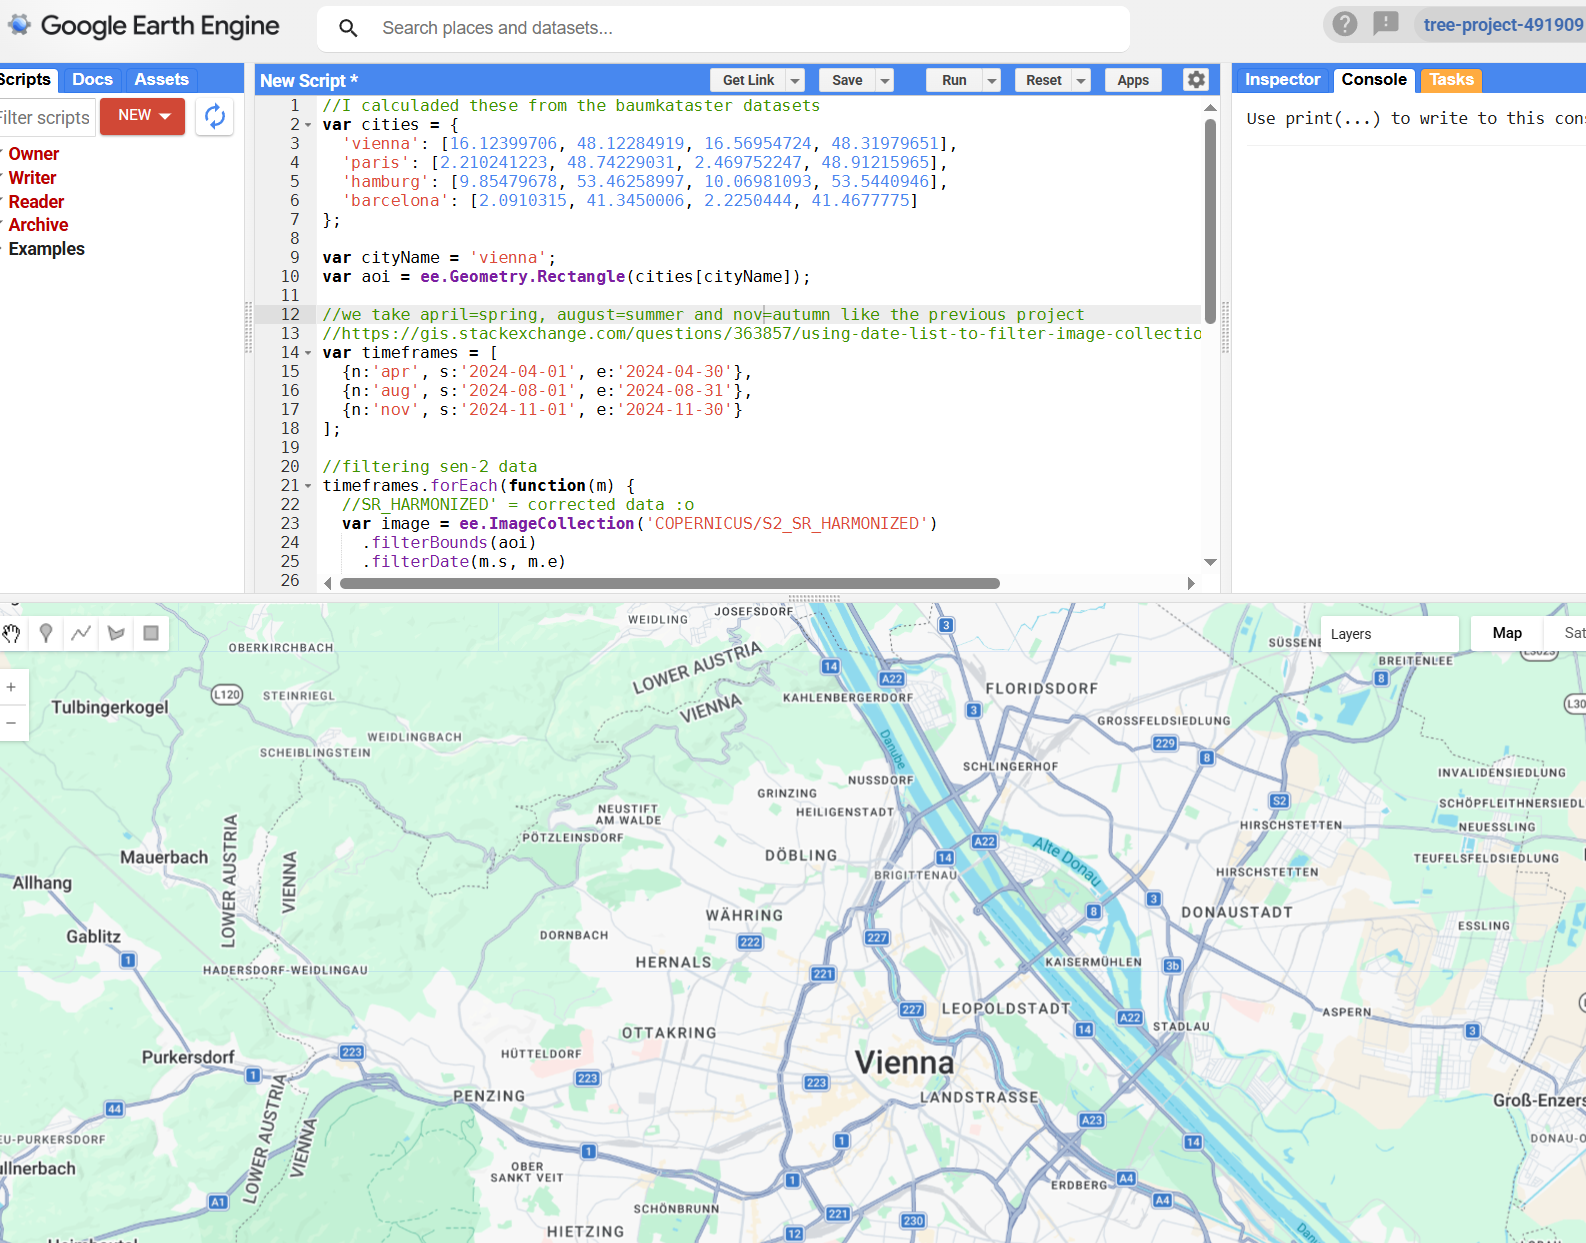

In [7]:
!pip install geopandas

In [10]:
#2.getting sential-2 satellite images
#B02=blue, B03=green, B04=red, B08=newinfrared
#NDVI = (B08-B04)/(B08+B04)
#spring -> april
#summer (july/august) → peak vegetation = full canopy
#autumn (octo/cov) → vegetation decline
#From: 2025-04-01 #Until: 2025-04-31
#From: 2025-08-01 #Until: 2025-08-31
#From: 2025-11-01#Until: 2025-11-31

#calculate poi or aoi for the rectangle box input
import pandas as pd
import geopandas as gpd

vienna = list(gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/vienna.gpkg").to_crs("EPSG:4326").total_bounds)
paris = list(gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/paris.gpkg").to_crs("EPSG:4326").total_bounds)
hamburg = list(gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/hamburg.gpkg").to_crs("EPSG:4326").total_bounds)
df = pd.read_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/baumkataster data/barcelona.parquet") #zwischenstep, weil es kein geometry column hat
barcelona = list(gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326").total_bounds)

print("vienna =", vienna)
print("paris =", paris)
print("hamburg =", hamburg)
print("barcelona =", barcelona)

vienna = [np.float64(16.12399706), np.float64(48.12284919), np.float64(16.56954724), np.float64(48.31979651)]
paris = [np.float64(2.2102412233046276), np.float64(48.74229030747077), np.float64(2.4697522469007653), np.float64(48.91215965335108)]
hamburg = [np.float64(9.854796779537846), np.float64(53.46258997436073), np.float64(10.069810928261486), np.float64(53.54409459709407)]
barcelona = [np.float64(2.0910315), np.float64(41.3450006), np.float64(2.2250444), np.float64(41.4677758)]


<blockquote>I calculated the "total_bounds" aka the points furthest on the side, which I can use to define the geomentry rectangle in the Javascript code below</blockquote>

Instead of manually selecting cloud-free imaged per month (as in the previous project), I applied a **median composite** over a filtered image collection using the Google Earth Engine API to reduce cloud coverage <a href="https://gis.stackexchange.com/questions/468569/filtering-clouds-and-creating-median-with-google-earth-engine-landsat8-evi-compo">(Source)</a><br>

- initial attempt (2024, 10% cloud filter) returned no usable images for Vienna Oct or Nov.
- adjusted parameters (2025, 20% cloud filter) produced images
- median compositing was used to effectively reduce remaining cloud artifacts.
- monthly selections vary slightly between cities (Paris uses **October** instead of November(=had no images in 2024 and 2025).


 ### <center>Image Counts by City and Month that got scraped</center>

| City      | Apr | Aug | Oct/Nov |
|-----------|-----|-----|---------|
| Vienna    | 6   | 14  | 8 (Nov) |
| Paris     | 17  | 16  | 3 (Oct) |
| Hamburg   | 6   | 4   | 1 (Nov) |
| Barcelona | 5   | 6   | 7 (Nov) |


### <u>Following Javascript code was used:</u>

```js
//I calculaded these from the baumkataster datasets
var cities = {'vienna': [16.12399706, 48.12284919, 16.56954724, 48.31979651], 'paris': [2.210241223, 48.74229031, 2.469752247, 48.91215965],
  'hamburg': [9.85479678, 53.46258997, 10.06981093, 53.5440946], 'barcelona': [2.0910315, 41.3450006, 2.2250444, 41.4677775]};
var cityName = 'vienna'; // too reuse it= efficient :p
var aoi = ee.Geometry.Rectangle(cities[cityName]);

//we take april=spring, august=summer and nov=autumn like the previous project
//https://gis.stackexchange.com/questions/363857/using-date-list-to-filter-image-collection-in-google-earth-engine (accessed 31.03 26)
[{n:'apr', s:'2025-04-01', e:'2025-04-30'},
 {n:'aug', s:'2025-08-01', e:'2025-08-31'},
 {n:'nov', s:'2025-11-01', e:'2025-11-30'}].forEach(function(m) {
  //filtering sen-2 data
  var s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') //SR_HARMONIZED' = corrected data :o
    .filterBounds(aoi)
    .filterDate(m.s, m.e)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20));
  var image = s2.median().clip(aoi); //make avg cloud free pic, recommendation from stackoverflow
  
  //checking if the year even has pics  
  print(cityName + ' ' + m.n + ' image count', s2.size()); 
  
  //calc ndvi, evi, savi like previous project
  var ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI');
  var evi = image.expression('2.5*((N-R) / (N+ 6*R-7.5*B+1))',
    {N: image.select('B8'), R: image.select('B4'), B: image.select('B2')}).rename('EVI');
  var savi = image.expression('1.5*((N-R) / (N+ R+ 0.5))',
    {N: image.select('B8'), R: image.select('B4')}).rename('SAVI');
  var stack = image.select(['B2','B3','B4','B8']).addBands([ndvi, evi, savi]).toFloat();
     
  //https://stackoverflow.com/questions/52450596/exporting-images-in-an-image-collection-from-gee (accessed 31.03.26)
  Export.image.toDrive({image: stack,
    description: 'S2_'+cityName+'_'+ m.n, folder: 'EarthEngineExports', //also has to define folder, else it was confused -> still better than copernicus
    scale: 10, region: aoi,
    fileFormat: 'GeoTIFF', maxPixels: 1e13 //got an error, had to max up the resolution
  });
     
  //https://developers.google.com/earth-engine/apidocs/map-addlayer (accessed 31.03.26)
  Map.addLayer(image,{bands:['B4','B3','B2'], min:0, max:3000}, cityName + '_' + m.n,false);
});

Map.centerObject(aoi, 12);
Map.addLayer(aoi, {}, cityName + '_AOI');
```

<blockquote>The resulting data is already cleaned as I implemented cloudy percentages and calculated the NDVI, EVI and SAVI similar to the <a href="https://github.com/tyomachkaa/WU-DataLab2026-infrared.city2/tree/main"> previous project</a>.</blockquote>

## OpenStreetMap Urban Features

https://download.geofabrik.de/europe/

In [23]:
import geopandas as gpd

#inspect data -> they all have the same 17 names
gpd.list_layers("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg")
#gpd.list_layers("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/ile-de-france.gpkg")
#gpd.list_layers("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/cataluna.gpkg")
#gpd.list_layers("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/hamburg.gpkg")

,name,geometry_type
0,gis_osm_natural_free,Point
1,gis_osm_traffic_free,Point
2,gis_osm_transport_free,Point
3,gis_osm_places_free,Point
4,gis_osm_pois_free,Point
5,gis_osm_pofw_free,Point
6,gis_osm_places_a_free,MultiPolygon
7,gis_osm_pofw_a_free,MultiPolygon
8,gis_osm_transport_a_free,MultiPolygon
9,gis_osm_pois_a_free,MultiPolygon


#### <center>Approx. Lat/long from the internet:</center>

| City      | Lon range   | Lat range   |
| --------- | ----------- | ----------- |
| Barcelona | 2.0 – 2.3   | 41.3 – 41.5 |
| Vienna    | 16.1 – 16.6 | 48.1 – 48.4 |
| Paris     | 2.2 – 2.5   | 48.8 – 49.0 |
| Hamburg   | 9.8 – 10.3  | 53.4 – 53.7 |
<br>

#### <center>Output from our Baumkataster from before (used to clip to the cities location):</center><br>
<center>vienna = [16.12399706, 48.12284919, 16.56954724, 48.31979651]</center><br>
<center>paris = [2.21024122, 48.74229031, 2.46975225, 48.91215965]</center><br>
<center>hamburg = [9.85479678, 53.46258997, 10.06981093, 53.5440946]</center><br>
<center>barcelona = [2.0910315, 41.3450006, 2.2250444, 41.4677758]</center><br>

In [27]:
print(vienna[0]) #testing just in case, im paranoid
print(paris[0])
print(barcelona[0])
print(hamburg[0])

16.12399706
2.2102412233046276
2.0910315
9.854796779537846


In [32]:
#vienna
roads_vienna = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_roads_free").to_crs(4326)
roads_vienna = roads_vienna.cx[vienna[0]:vienna[2], vienna[1]:vienna[3]] #here we clip to the location using baumkataster data
buildings_vienna = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_buildings_a_free").to_crs(4326)
buildings_vienna = buildings_vienna.cx[vienna[0]:vienna[2], vienna[1]:vienna[3]]
landuse_vienna = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_landuse_a_free").to_crs(4326)
landuse_vienna = landuse_vienna.cx[vienna[0]:vienna[2], vienna[1]:vienna[3]]
water_vienna = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/austria.gpkg", layer="gis_osm_water_a_free").to_crs(4326)
water_vienna = water_vienna.cx[vienna[0]:vienna[2], vienna[1]:vienna[3]]

roads_vienna.head()
buildings_vienna.head()
landuse_vienna.head()
water_vienna.head()

,osm_id,code,fclass,name,geometry
46,3870590,8200,water,Transportbetongrube,"MULTIPOLYGON (((16.48996 48.27031, 16.48998 48..."
54,3870688,8200,water,Schießstattlacke,"MULTIPOLYGON (((16.42203 48.23973, 16.4221 48...."
55,3870690,8200,water,Irissee,"MULTIPOLYGON (((16.41198 48.24108, 16.41198 48..."
56,3870694,8200,water,Kaiserwasser,"MULTIPOLYGON (((16.41813 48.2324, 16.41814 48...."
64,4598317,8200,water,Freudenauer Hafen,"MULTIPOLYGON (((16.46172 48.1825, 16.46417 48...."


In [33]:
# paris
roads_paris = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/ile-de-france.gpkg", layer="gis_osm_roads_free").to_crs(4326)
roads_paris = roads_paris.cx[paris[0]:paris[2], paris[1]:paris[3]]
buildings_paris = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/ile-de-france.gpkg", layer="gis_osm_buildings_a_free").to_crs(4326)
buildings_paris = buildings_paris.cx[paris[0]:paris[2], paris[1]:paris[3]]
landuse_paris = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/ile-de-france.gpkg", layer="gis_osm_landuse_a_free").to_crs(4326)
landuse_paris = landuse_paris.cx[paris[0]:paris[2], paris[1]:paris[3]]
water_paris = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/ile-de-france.gpkg", layer="gis_osm_water_a_free").to_crs(4326)
water_paris = water_paris.cx[paris[0]:paris[2], paris[1]:paris[3]]

roads_paris.head()
buildings_paris.head()
landuse_paris.head()
water_paris.head()

,osm_id,code,fclass,name,geometry
0,4082329,8202,riverbank,Bassin de l'Arsenal,"MULTIPOLYGON (((2.366 48.84736, 2.36607 48.847..."
2,4294027,8200,water,,"MULTIPOLYGON (((2.33687 48.84679, 2.33706 48.8..."
3,4430591,8200,water,Étang de Suresnes,"MULTIPOLYGON (((2.23027 48.86289, 2.23034 48.8..."
17,13862341,8200,water,Bassin Louis Blanc,"MULTIPOLYGON (((2.36756 48.87991, 2.36764 48.8..."
18,13862344,8200,water,Double Écluse des Morts,"MULTIPOLYGON (((2.36566 48.87764, 2.36572 48.8..."


In [34]:
#barcelona
roads_barcelona = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/cataluna.gpkg", layer="gis_osm_roads_free").to_crs(4326)
roads_barcelona = roads_barcelona.cx[barcelona[0]:barcelona[2], barcelona[1]:barcelona[3]]
buildings_barcelona = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/cataluna.gpkg", layer="gis_osm_buildings_a_free").to_crs(4326)
buildings_barcelona = buildings_barcelona.cx[barcelona[0]:barcelona[2], barcelona[1]:barcelona[3]]
landuse_barcelona = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/cataluna.gpkg", layer="gis_osm_landuse_a_free").to_crs(4326)
landuse_barcelona = landuse_barcelona.cx[barcelona[0]:barcelona[2], barcelona[1]:barcelona[3]]
water_barcelona = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/cataluna.gpkg", layer="gis_osm_water_a_free").to_crs(4326)
water_barcelona = water_barcelona.cx[barcelona[0]:barcelona[2], barcelona[1]:barcelona[3]]

roads_barcelona.head()
buildings_barcelona.head()
landuse_barcelona.head()
water_barcelona.head()

,osm_id,code,fclass,name,geometry
45,35816134,8200,water,Font Màgica de Montjuïc,"MULTIPOLYGON (((2.15138 41.37108, 2.15138 41.3..."
47,37953216,8200,water,,"MULTIPOLYGON (((2.19606 41.45632, 2.1961 41.45..."
141,54866872,8200,water,,"MULTIPOLYGON (((2.16852 41.40938, 2.16878 41.4..."
143,56688067,8200,water,,"MULTIPOLYGON (((2.13926 41.37739, 2.13926 41.3..."
149,61299379,8200,water,,"MULTIPOLYGON (((2.11509 41.38894, 2.11509 41.3..."


In [35]:
#hamburg
roads_hamburg = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/hamburg.gpkg", layer="gis_osm_roads_free").to_crs(4326)
roads_hamburg = roads_hamburg.cx[hamburg[0]:hamburg[2], hamburg[1]:hamburg[3]]
buildings_hamburg = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/hamburg.gpkg", layer="gis_osm_buildings_a_free").to_crs(4326)
buildings_hamburg = buildings_hamburg.cx[hamburg[0]:hamburg[2], hamburg[1]:hamburg[3]]
landuse_hamburg = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/hamburg.gpkg", layer="gis_osm_landuse_a_free").to_crs(4326)
landuse_hamburg = landuse_hamburg.cx[hamburg[0]:hamburg[2], hamburg[1]:hamburg[3]]
water_hamburg = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/raw data/osm data/hamburg.gpkg", layer="gis_osm_water_a_free").to_crs(4326)
water_hamburg = water_hamburg.cx[hamburg[0]:hamburg[2], hamburg[1]:hamburg[3]]

roads_hamburg.head()
buildings_hamburg.head()
landuse_hamburg.head()
water_hamburg.head()

,osm_id,code,fclass,name,geometry
0,3220277,8200,water,Kretortteich,"MULTIPOLYGON (((9.87689 53.48389, 9.87689 53.4..."
1,3220294,8200,water,Neuwiedenthaler Teich,"MULTIPOLYGON (((9.88168 53.4833, 9.88168 53.48..."
2,4070471,8200,water,,"MULTIPOLYGON (((9.86461 53.54126, 9.86487 53.5..."
3,4097009,8200,water,,"MULTIPOLYGON (((10.02412 53.52495, 10.02484 53..."
4,4102792,8203,dock,Dock 11,"MULTIPOLYGON (((9.95329 53.54212, 9.95346 53.5..."


## <b>2. Checking osm data</b>
### Checking geometry validity

In [38]:
roads_vienna.is_valid.value_counts()
buildings_vienna.is_valid.value_counts()
landuse_vienna.is_valid.value_counts()
water_vienna.is_valid.value_counts()

True    1344
Name: count, dtype: int64

In [40]:
roads_paris.is_valid.value_counts()
buildings_paris.is_valid.value_counts()
landuse_paris.value_counts()
water_paris.is_valid.value_counts()

True    1158
Name: count, dtype: int64

In [41]:
roads_barcelona.is_valid.value_counts()
buildings_barcelona.is_valid.value_counts()
landuse_barcelona.is_valid.value_counts()
water_barcelona.is_valid.value_counts()

True    323
Name: count, dtype: int64

In [42]:
roads_hamburg.is_valid.value_counts()
buildings_hamburg.is_valid.value_counts()
landuse_hamburg.is_valid.value_counts()
water_hamburg.is_valid.value_counts()

True    559
Name: count, dtype: int64

<blockquote>As there are only <code>True</code> values, the geometry seems to be fine.</blockquote>

### Checking empty geometries

In [43]:
roads_vienna.geometry.is_empty.sum()
buildings_vienna.geometry.is_empty.sum()
landuse_vienna.geometry.is_empty.sum()
water_vienna.geometry.is_empty.sum()

np.int64(0)

In [44]:
roads_paris.geometry.is_empty.sum()
buildings_paris.geometry.is_empty.sum()
landuse_paris.geometry.is_empty.sum()
water_paris.geometry.is_empty.sum()

np.int64(0)

In [45]:
roads_barcelona.geometry.is_empty.sum()
buildings_barcelona.geometry.is_empty.sum()
landuse_barcelona.geometry.is_empty.sum()
water_barcelona.geometry.is_empty.sum()

np.int64(0)

In [46]:
roads_hamburg.geometry.is_empty.sum()
buildings_hamburg.geometry.is_empty.sum()
landuse_hamburg.geometry.is_empty.sum()
water_hamburg.geometry.is_empty.sum()

np.int64(0)

<blockquote>As there are only <code>0</code> values in sum, the geometry seems not to be empty.</blockquote>

## Filtering
Uncomment rows if you want to inspect it:

In [71]:
#roads_vienna["fclass"].value_counts()
#buildings_vienna["fclass"].value_counts() # looks good only hase buildings as fclass
#landuse_vienna["fclass"].value_counts()
water_vienna["fclass"].value_counts() #water looks fine for all 4 cities, maybe removing docks later while modeling

fclass
water        1055
wetland       209
riverbank      43
reservoir      37
Name: count, dtype: int64

In [72]:
#roads_paris["fclass"].value_counts()
#buildings_paris["fclass"].value_counts()
#landuse_paris["fclass"].value_counts()
water_paris["fclass"].value_counts()

fclass
water        1017
reservoir      57
wetland        50
riverbank      34
Name: count, dtype: int64

In [73]:
#roads_barcelona["fclass"].value_counts()
#buildings_barcelona["fclass"].value_counts()
#landuse_barcelona["fclass"].value_counts()
water_barcelona["fclass"].value_counts()

fclass
water        308
reservoir      8
wetland        4
dock           2
riverbank      1
Name: count, dtype: int64

In [74]:
#roads_hamburg["fclass"].value_counts()
#buildings_hamburg["fclass"].value_counts()
#landuse_hamburg["fclass"].value_counts()
water_hamburg["fclass"].value_counts()

fclass
water        437
wetland       79
reservoir     19
riverbank     14
dock          10
Name: count, dtype: int64

## Feature Overview

At this stage, OpenStreetMap (OSM) data were cleaned aka. checked to the study areas (Vienna, Paris, Hamburg, Barcelona).<br>
No aggressive filtering was applied yet in order to preserve flexibility for modeling:<br>

---
#### Buildings

* Only class: `building`

#### Roads

* Dominated by: `footway`, `service`, `residential`
* Also includes: `primary`, `secondary`, `tertiary`, `motorway`
* Maybe drop: `footway`, `path`, `track`, `steps`

#### Land Use

* Green: `grass`, `forest`, `meadow`, `scrub`, `park`
* Urban: `residential`, `industrial`, `commercial`
* Other: `farmland`, `vineyard`, `military`, etc.
* Maybe drop: agricultural / rare classes

#### Water

* Main: `water`, `reservoir`, `riverbank`
* Maybe drop: `wetland`, `dock` (only has few)

## <b>3. Saving osm data (sentinel already saved)</b>

In [75]:
#/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg parquet
#geojson vienna
roads_vienna.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/vienna_osm.gpkg", layer="roads", driver="GPKG")
buildings_vienna.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/vienna_osm.gpkg", layer="buildings", driver="GPKG")
landuse_vienna.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/vienna_osm.gpkg", layer="landuse", driver="GPKG")
water_vienna.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/vienna_osm.gpkg", layer="water", driver="GPKG")

#parquet
roads_vienna.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/roads_vienna.parquet")
buildings_vienna.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/buildings_vienna.parquet")
landuse_vienna.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/landuse_vienna.parquet")
water_vienna.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/water_vienna.parquet")

In [76]:
#geojson paris
roads_paris.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/paris_osm.gpkg", layer="roads", driver="GPKG")
buildings_paris.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/paris_osm.gpkg", layer="buildings", driver="GPKG")
landuse_paris.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/paris_osm.gpkg", layer="landuse", driver="GPKG")
water_paris.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/paris_osm.gpkg", layer="water", driver="GPKG")

#parquet
roads_paris.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/roads_paris.parquet")
buildings_paris.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/buildings_paris.parquet")
landuse_paris.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/landuse_paris.parquet")
water_paris.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/water_paris.parquet")

In [77]:
#geojson barcelona_osm
roads_barcelona.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/barcelona_osm.gpkg", layer="roads", driver="GPKG")
buildings_barcelona.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/barcelona_osm.gpkg", layer="buildings", driver="GPKG")
landuse_barcelona.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/barcelona_osm.gpkg", layer="landuse", driver="GPKG")
water_barcelona.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/barcelona_osm.gpkg", layer="water", driver="GPKG")

#parquet
roads_barcelona.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/roads_barcelona.parquet")
buildings_barcelona.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/buildings_barcelona.parquet")
landuse_barcelona.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/landuse_barcelona.parquet")
water_barcelona.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/water_barcelona.parquet")

In [78]:
#geojson hamburg_osm
roads_hamburg.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/hamburg_osm.gpkg", layer="roads", driver="GPKG")
buildings_hamburg.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/hamburg_osm.gpkg", layer="buildings", driver="GPKG")
landuse_hamburg.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/hamburg_osm.gpkg", layer="landuse", driver="GPKG")
water_hamburg.to_file("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/gpkg/hamburg_osm.gpkg", layer="water", driver="GPKG")

#parquet
roads_hamburg.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/roads_hamburg.parquet")
buildings_hamburg.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/buildings_hamburg.parquet")
landuse_hamburg.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/landuse_hamburg.parquet")
water_hamburg.to_parquet("/home/jovyan/ideas-dslab-group1-shared/cleaned data/osm data/parquet/water_hamburg.parquet")

<blockquote>The cleaned OpenStreetMap layers were stored as GeoPackage files and additionally exported as Parquet files.</blockquote>